In [1]:
import pandas as pd

df = pd.read_csv("train_clean.csv")

In [2]:
df

,issue_title,body,body_clean
0,timeout while resolving completions!,"hello, i'm trying to go to the definition of m...",<s> hello i m trying to go to the definition o...
1,ntr high-affinity potassium ion import across ...,"hi, i'd like to request the term high-affinity...",<s> hi i d like to request the term high affin...
2,documenting serde types,"hi, i'm using serde to define a web api that u...",<s> hi i m using serde to define a web api tha...
3,level 5 counts 12:xx as later than all other t...,the implementation of level 5 is confusing. 12...,<s> the implementation of level [num] is confu...
4,surely it's late but for a nooby .. step by st...,"ok for docker .. all done, find it there!: htt...",<s> ok for docker all done find it there [url]...
...,...,...,...
159995,spike define criterias for reports,for front end will be used http://www.chartjs....,<s> for front end will be used [url] that will...
159996,no default jsdelivr cdn file set,this package doesn't have a default file https...,<s> this package doesn t have a default file [...
159997,goo jerrycan acting wierd,i can't craft it now for some reason also unlo...,<s> i can t craft it now for some reason also ...
159998,enable continuous integration,a .travis.yml file is required at project root...,<s> a travis yml file is required at project r...


# POS-tagging

## EDA

### NLTK

`tagset='default'` — Penn Treebank, метки `nltk.pos_tag`. `tagset='universal'` — крупный набор из 12 меток.

#### default

| Тег | Часть речи |
|---|---|
| `NN` | существительное, нарицательное, единственное число или неисчисляемое |
| `NNS` | существительное, нарицательное, множественное число |
| `NNP` | имя собственное, единственное число |
| `NNPS` | имя собственное, множественное число |
| `VB` | глагол, начальная форма |
| `VBD` | глагол, прошедшее время |
| `VBG` | глагол, причастие настоящего времени или герундий |
| `VBN` | глагол, причастие прошедшего времени |
| `VBP` | глагол, настоящее время, не 3-е лицо единственного числа |
| `VBZ` | глагол, настоящее время, 3-е лицо единственного числа |
| `MD` | модальный глагол |
| `JJ` | прилагательное или порядковое числительное |
| `JJR` | прилагательное, сравнительная степень |
| `JJS` | прилагательное, превосходная степень |
| `RB` | наречие |
| `RBR` | наречие, сравнительная степень |
| `RBS` | наречие, превосходная степень |
| `WRB` | вопросительное наречие |
| `RP` | частица |
| `PRP` | личное местоимение |
| `PRP$` | притяжательное местоимение |
| `WP` | вопросительное местоимение |
| `WP$` | притяжательное вопросительное местоимение |
| `DT` | определитель |
| `PDT` | предопределитель |
| `WDT` | вопросительный определитель |
| `EX` | экзистенциальное *there* |
| `CC` | сочинительный союз |
| `IN` | предлог или подчинительный союз |
| `TO` | *to* как предлог или показатель инфинитива |
| `CD` | количественное числительное |
| `POS` | показатель притяжательности |
| `UH` | междометие |
| `FW` | иностранное слово |
| `LS` | маркер пункта списка |
| `SYM` | символ |
| `$` | знак доллара |
| `.` | конец предложения |
| `,` | запятая |
| `:` | двоеточие или многоточие |
| `--` | тире |
| `(` | открывающая скобка |
| `)` | закрывающая скобка |
| <code>``</code> | открывающая кавычка |
| `''` | закрывающая кавычка |

#### universal

| Тег | Часть речи |
|---|---|
| `ADJ` | прилагательное |
| `ADP` | предлог |
| `ADV` | наречие |
| `CONJ` | союз |
| `DET` | определитель |
| `NOUN` | существительное |
| `NUM` | числительное |
| `PRON` | местоимение |
| `PRT` | частица |
| `VERB` | глагол |
| `.` | пунктуация |
| `X` | другое |

In [3]:
import nltk
from nltk.tag import pos_tag
from nltk.tokenize import word_tokenize

#  nltk.download('universal_tagset')
#  nltk.download('tagsets_json')

In [4]:
text_col = "body_clean"


for i in range(10):
    print("--" * 50)
    print(f"Source: {df.iloc[i][text_col]}")
    print(f"tagset='default': {pos_tag(word_tokenize(df.iloc[i][text_col]))}")
    print(f"tagset='universal': {pos_tag(word_tokenize(df.iloc[i][text_col]), tagset='universal')}")

----------------------------------------------------------------------------------------------------
Source: <s> hello i m trying to go to the definition of my function method but i m getting a timeout i tried with alt left click as documentation said this error occurs in st [num] and [num] can you help me </s>
tagset='default': [('<', 'JJ'), ('s', 'NN'), ('>', 'NNP'), ('hello', 'NN'), ('i', 'NN'), ('m', 'VBP'), ('trying', 'VBG'), ('to', 'TO'), ('go', 'VB'), ('to', 'TO'), ('the', 'DT'), ('definition', 'NN'), ('of', 'IN'), ('my', 'PRP$'), ('function', 'NN'), ('method', 'NN'), ('but', 'CC'), ('i', 'JJ'), ('m', 'VBP'), ('getting', 'VBG'), ('a', 'DT'), ('timeout', 'NN'), ('i', 'NN'), ('tried', 'VBD'), ('with', 'IN'), ('alt', 'NN'), ('left', 'VBD'), ('click', 'NN'), ('as', 'IN'), ('documentation', 'NN'), ('said', 'VBD'), ('this', 'DT'), ('error', 'NN'), ('occurs', 'VBZ'), ('in', 'IN'), ('st', 'JJ'), ('[', 'NNP'), ('num', 'NN'), (']', 'NN'), ('and', 'CC'), ('[', 'NNP'), ('num', 'RB'), (']', 

In [5]:
text_col = "body"


for i in range(10):
    print("--" * 50)
    print(f"Source: {df.iloc[i][text_col]}")
    print(f"tagset='default': {pos_tag(word_tokenize(df.iloc[i][text_col]))}")
    print(f"tagset='universal': {pos_tag(word_tokenize(df.iloc[i][text_col]), tagset='universal')}")

----------------------------------------------------------------------------------------------------
Source: hello, i'm trying to go to the definition of my function / method, but i'm getting a timeout : i tried with alt + left click as documentation said . this error occurs in st 2 and 3. can you help me?
tagset='default': [('hello', 'NN'), (',', ','), ('i', 'JJ'), ("'m", 'VBP'), ('trying', 'VBG'), ('to', 'TO'), ('go', 'VB'), ('to', 'TO'), ('the', 'DT'), ('definition', 'NN'), ('of', 'IN'), ('my', 'PRP$'), ('function', 'NN'), ('/', 'NNP'), ('method', 'NN'), (',', ','), ('but', 'CC'), ('i', 'JJ'), ("'m", 'VBP'), ('getting', 'VBG'), ('a', 'DT'), ('timeout', 'NN'), (':', ':'), ('i', 'NN'), ('tried', 'VBD'), ('with', 'IN'), ('alt', 'NN'), ('+', 'NN'), ('left', 'VBD'), ('click', 'NN'), ('as', 'IN'), ('documentation', 'NN'), ('said', 'VBD'), ('.', '.'), ('this', 'DT'), ('error', 'NN'), ('occurs', 'VBZ'), ('in', 'IN'), ('st', 'JJ'), ('2', 'CD'), ('and', 'CC'), ('3.', 'CD'), ('can', 'MD'), ('y

###  SpaCy

`tagset='default'` — мелкие метки `token.tag_` (Penn Treebank). `tagset='universal'` — крупные метки `token.pos_` (Universal Dependencies, 17 тегов).

#### default

| Тег | Часть речи |
|---|---|
| `NN` | существительное, единственное число или неисчисляемое |
| `NNS` | существительное, множественное число |
| `NNP` | имя собственное, единственное число |
| `NNPS` | имя собственное, множественное число |
| `VB` | глагол, начальная форма |
| `VBD` | глагол, прошедшее время |
| `VBG` | глагол, герундий или причастие настоящего времени |
| `VBN` | глагол, причастие прошедшего времени |
| `VBP` | глагол, настоящее время, не 3-е лицо единственного числа |
| `VBZ` | глагол, настоящее время, 3-е лицо единственного числа |
| `MD` | модальный глагол |
| `JJ` | прилагательное |
| `JJR` | прилагательное, сравнительная степень |
| `JJS` | прилагательное, превосходная степень |
| `RB` | наречие |
| `RBR` | наречие, сравнительная степень |
| `RBS` | наречие, превосходная степень |
| `WRB` | вопросительное наречие |
| `RP` | глагольная частица |
| `PRP` | личное местоимение |
| `PRP$` | притяжательное местоимение |
| `WP` | вопросительное местоимение |
| `WP$` | притяжательное вопросительное местоимение |
| `DT` | определитель |
| `PDT` | предопределитель |
| `WDT` | вопросительный определитель |
| `EX` | экзистенциальное *there* |
| `CC` | сочинительный союз |
| `IN` | предлог или подчинительный союз |
| `TO` | инфинитивное *to* |
| `CD` | количественное числительное |
| `POS` | притяжательное окончание *'s* |
| `UH` | междометие |
| `FW` | иностранное слово |
| `AFX` | аффикс |
| `LS` | маркер пункта списка |
| `ADD` | адрес электронной почты |
| `XX` | неизвестный токен |
| `SYM` | символ |
| `$` | символ валюты |
| `.` | точка, конец предложения |
| `,` | запятая |
| `:` | двоеточие или многоточие |
| `HYPH` | дефис |
| `NFP` | лишняя пунктуация |
| `-LRB-` | открывающая скобка |
| `-RRB-` | закрывающая скобка |
| <code>``</code> | открывающая кавычка |
| `''` | закрывающая кавычка |
| `_SP` | пробел |

#### universal

| Тег | Часть речи |
|---|---|
| `ADJ` | прилагательное |
| `ADP` | предлог |
| `ADV` | наречие |
| `AUX` | вспомогательный глагол |
| `CCONJ` | сочинительный союз |
| `DET` | определитель |
| `INTJ` | междометие |
| `NOUN` | существительное |
| `NUM` | числительное |
| `PART` | частица |
| `PRON` | местоимение |
| `PROPN` | имя собственное |
| `PUNCT` | пунктуация |
| `SCONJ` | подчинительный союз |
| `SYM` | символ |
| `VERB` | глагол |
| `X` | другое |

In [6]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [7]:
text_col = "body_clean"


for i in range(10):
    print("--" * 50)
    print(f"Source: {df.iloc[i][text_col]}")
    doc = nlp(df.iloc[i][text_col])
    print(f"tagset='default': {[(token.text, token.tag_) for token in doc]}")
    print(f"tagset='universal': {[(token.text, token.pos_) for token in doc]}")

----------------------------------------------------------------------------------------------------
Source: <s> hello i m trying to go to the definition of my function method but i m getting a timeout i tried with alt left click as documentation said this error occurs in st [num] and [num] can you help me </s>
tagset='default': [('<', 'ADD'), ('s', 'XX'), ('>', 'XX'), ('hello', 'UH'), ('i', 'PRP'), ('m', 'VBP'), ('trying', 'VBG'), ('to', 'TO'), ('go', 'VB'), ('to', 'IN'), ('the', 'DT'), ('definition', 'NN'), ('of', 'IN'), ('my', 'PRP$'), ('function', 'NN'), ('method', 'NN'), ('but', 'CC'), ('i', 'PRP'), ('m', 'VBP'), ('getting', 'VBG'), ('a', 'DT'), ('timeout', 'NN'), ('i', 'PRP'), ('tried', 'VBD'), ('with', 'IN'), ('alt', 'NN'), ('left', 'VBN'), ('click', 'VB'), ('as', 'IN'), ('documentation', 'NN'), ('said', 'VBD'), ('this', 'DT'), ('error', 'NN'), ('occurs', 'VBZ'), ('in', 'IN'), ('st', 'NNP'), ('[', 'XX'), ('num', 'XX'), (']', 'XX'), ('and', 'CC'), ('[', 'XX'), ('num', 'XX'), (']'

In [8]:
text_col = "body"


for i in range(10):
    print("--" * 50)
    print(f"Source: {df.iloc[i][text_col]}")
    doc = nlp(df.iloc[i][text_col])
    print(f"tagset='default': {[(token.text, token.tag_) for token in doc]}")
    print(f"tagset='universal': {[(token.text, token.pos_) for token in doc]}")

----------------------------------------------------------------------------------------------------
Source: hello, i'm trying to go to the definition of my function / method, but i'm getting a timeout : i tried with alt + left click as documentation said . this error occurs in st 2 and 3. can you help me?
tagset='default': [('hello', 'UH'), (',', ','), ('i', 'PRP'), ("'m", 'VBP'), ('trying', 'VBG'), ('to', 'TO'), ('go', 'VB'), ('to', 'IN'), ('the', 'DT'), ('definition', 'NN'), ('of', 'IN'), ('my', 'PRP$'), ('function', 'NN'), ('/', 'SYM'), ('method', 'NN'), (',', ','), ('but', 'CC'), ('i', 'PRP'), ("'m", 'VBP'), ('getting', 'VBG'), ('a', 'DT'), ('timeout', 'NN'), (':', ':'), ('i', 'PRP'), ('tried', 'VBD'), ('with', 'IN'), ('alt', 'NN'), ('+', 'CC'), ('left', 'VBN'), ('click', 'VB'), ('as', 'IN'), ('documentation', 'NN'), ('said', 'VBD'), ('.', '.'), ('this', 'DT'), ('error', 'NN'), ('occurs', 'VBZ'), ('in', 'IN'), ('st', 'NNP'), ('2', 'CD'), ('and', 'CC'), ('3', 'CD'), ('.', '.'), ('c

tagset='default': [('the', 'DT'), ('implementation', 'NN'), ('of', 'IN'), ('level', 'NN'), ('5', 'CD'), ('is', 'VBZ'), ('confusing', 'JJ'), ('.', '.'), ('12:00', 'CD'), ('should', 'MD'), ('be', 'VB'), ('considered', 'VBN'), ('earlier', 'RBR'), ('than', 'IN'), ('all', 'DT'), ('other', 'JJ'), ('times', 'NNS'), ('.', '.'), ('-', ':'), ('make', 'VB'), ('the', 'DT'), ('hour', 'NN'), ('range', 'NN'), ('in', 'IN'), ('level', 'NN'), ('5', 'CD'), ('from', 'IN'), ('0', 'CD'), ('to', 'IN'), ('11', 'CD'), ('rather', 'RB'), ('than', 'IN'), ('1', 'CD'), ('to', 'TO'), ('12', 'CD')]
tagset='universal': [('the', 'DET'), ('implementation', 'NOUN'), ('of', 'ADP'), ('level', 'NOUN'), ('5', 'NUM'), ('is', 'AUX'), ('confusing', 'ADJ'), ('.', 'PUNCT'), ('12:00', 'NUM'), ('should', 'AUX'), ('be', 'AUX'), ('considered', 'VERB'), ('earlier', 'ADV'), ('than', 'ADP'), ('all', 'DET'), ('other', 'ADJ'), ('times', 'NOUN'), ('.', 'PUNCT'), ('-', 'PUNCT'), ('make', 'VERB'), ('the', 'DET'), ('hour', 'NOUN'), ('range', 

# Анализ распределения

Корпус состоит из 160 000 документов — слишком много, чтобы гонять оба тэггера по всему корпусу в учебном ноутбуке за разумное время. Поэтому для количественного анализа берём воспроизводимую случайную подвыборку, а тэггеры сравниваем по `tagset='universal'` (12 меток у NLTK, 17 — у SpaCy, т.к. в SpaCy `PROPN`, `AUX`, `PUNCT`, `SYM`, `SCONJ`/`CCONJ`, `INTJ`, `SPACE` вынесены отдельно, а не слиты с `NOUN`/`VERB`/`.`/`CONJ`, как у NLTK).

Колонка для анализа — `body` (как и в лабораторной №1): в отличие от `body_clean`, здесь сохранены исходные числа, url и пунктуация, поэтому распределение частей речи получается более показательным (а не искусственно раздутым токенами `[num]`/`[url]`).

In [9]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

SAMPLE_SIZE = 6000
RANDOM_STATE = 42

sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
texts = sample["body"].astype(str).tolist()

print(f"Размер подвыборки: {len(texts)} документов")

Matplotlib is building the font cache; this may take a moment.


Размер подвыборки: 6000 документов


### Частотное распределение частей речи по всему корпусу (подвыборке)

In [10]:
nltk_counter = Counter()
for t in texts:
    tags = pos_tag(word_tokenize(t), tagset="universal")
    nltk_counter.update(tag for _, tag in tags)

nltk_total = sum(nltk_counter.values())
print(f"NLTK, всего токенов: {nltk_total}")
for tag, cnt in nltk_counter.most_common():
    print(f"{tag:>6}: {cnt:>7} ({cnt / nltk_total:5.1%})")

NLTK, всего токенов: 445927
  NOUN:  138118 (31.0%)
  VERB:   69046 (15.5%)
     .:   65606 (14.7%)
   ADJ:   40994 ( 9.2%)
   DET:   33421 ( 7.5%)
   ADP:   32768 ( 7.3%)
   ADV:   18481 ( 4.1%)
   NUM:   12630 ( 2.8%)
   PRT:   12413 ( 2.8%)
  PRON:   11200 ( 2.5%)
  CONJ:    9894 ( 2.2%)
     X:    1356 ( 0.3%)


In [11]:
spacy_counter = Counter()
for doc in nlp.pipe(texts, batch_size=64, disable=["parser", "ner", "lemmatizer"]):
    spacy_counter.update(tok.pos_ for tok in doc)

spacy_total = sum(spacy_counter.values())
print(f"SpaCy, всего токенов: {spacy_total}")
for tag, cnt in spacy_counter.most_common():
    print(f"{tag:>6}: {cnt:>7} ({cnt / spacy_total:5.1%})")

SpaCy, всего токенов: 460120
  NOUN:  105786 (23.0%)
 PUNCT:   67811 (14.7%)
  VERB:   47503 (10.3%)
   DET:   32109 ( 7.0%)
 PROPN:   31921 ( 6.9%)
   ADP:   31594 ( 6.9%)
   AUX:   22788 ( 5.0%)
   ADJ:   22728 ( 4.9%)
  PRON:   20236 ( 4.4%)
   NUM:   14541 ( 3.2%)
   ADV:   13028 ( 2.8%)
  PART:   11508 ( 2.5%)
     X:    9811 ( 2.1%)
   SYM:    9519 ( 2.1%)
 CCONJ:    9442 ( 2.1%)
 SCONJ:    6981 ( 1.5%)
  INTJ:    1785 ( 0.4%)
 SPACE:    1029 ( 0.2%)


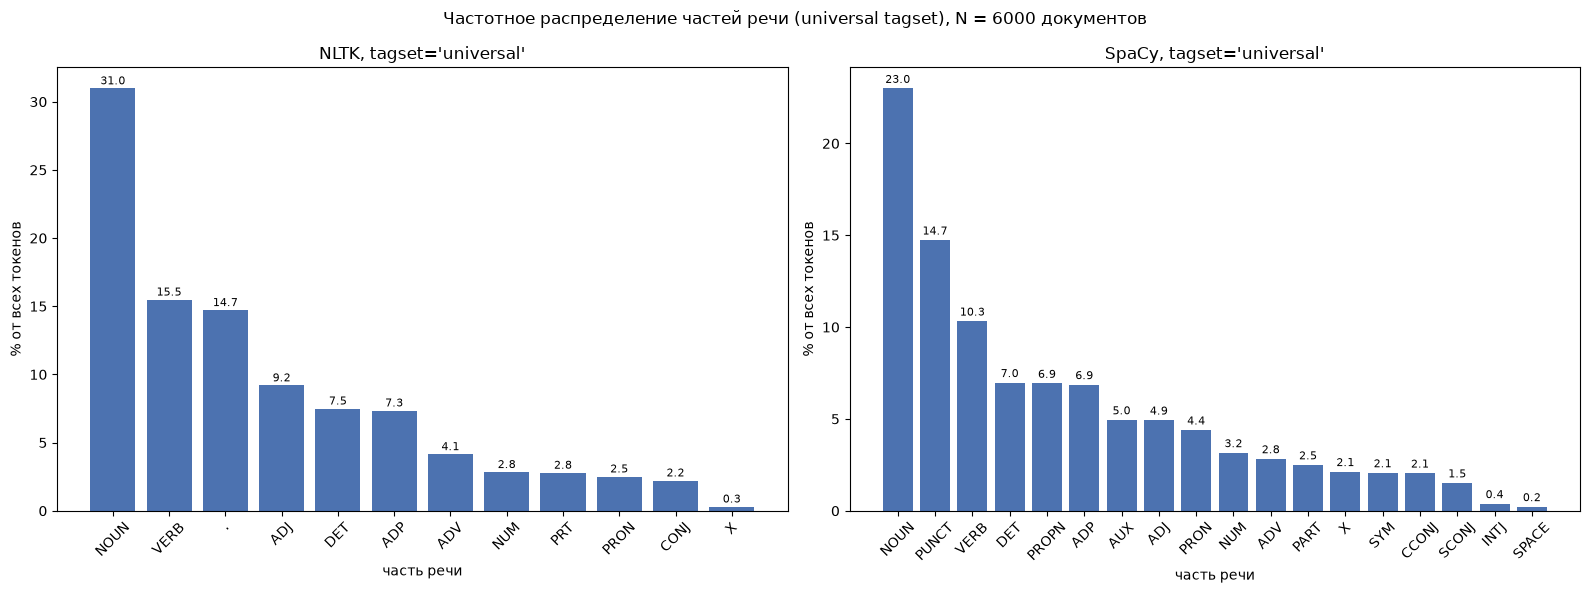

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, counter, total, title in [
    (axes[0], nltk_counter, nltk_total, "NLTK, tagset='universal'"),
    (axes[1], spacy_counter, spacy_total, "SpaCy, tagset='universal'"),
]:
    tags, counts = zip(*counter.most_common())
    freqs = [c / total * 100 for c in counts]
    bars = ax.bar(tags, freqs, color="#4C72B0")
    ax.set_title(title)
    ax.set_xlabel("часть речи")
    ax.set_ylabel("% от всех токенов")
    ax.tick_params(axis="x", rotation=45)
    for bar, freq in zip(bars, freqs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f"{freq:.1f}", ha="center", fontsize=8)

fig.suptitle(f"Частотное распределение частей речи (universal tagset), N = {len(texts)} документов")
fig.tight_layout()
plt.show()

**Наблюдения по всему корпусу:**

- Оба тэггера сходятся в главном: доминируют `NOUN` (существительные) и `VERB` (глаголы) — ожидаемо для технических issue-репортов, где описываются объекты системы (модули, функции, файлы) и действия/ошибки, которые с ними происходят.
- У NLTK пунктуация (`.`) занимает 2-е место (≈14.7%) — в его universal tagset в один тег `.` схлопнуты все знаки препинания. У SpaCy аналогичная по смыслу категория `PUNCT` тоже на 2-м месте (≈14.7%), но у SpaCy отдельно выделен `SYM` (≈2.1%, символы вроде `/`, `:`, `--`) и `X` (≈2.1%, неразобранные токены — url, хэши, код), которые у NLTK либо попадают в `.`, либо размазаны по `NOUN`/`ADJ`.
- Главное структурное отличие тэгсетов: у SpaCy ощутимую долю (≈6.9%) занимает `PROPN` (имена собственные — названия библиотек, файлов, пользователей), тогда как у NLTK `PROPN` как отдельного тега в universal-маппинге нет — все существительные (нарицательные и собственные) сливаются в `NOUN`, поэтому у NLTK доля `NOUN` заметно выше (≈31%) по сравнению со SpaCy (≈23%), хотя по сути означает примерно то же самое.

### Сравнение по классам документов: bug-репорты vs feature-запросы

В датасете GitHub Issues нет готовой метки класса документа, поэтому класс извлекается эвристически по `issue_title`: ищем ключевые слова, типичные для багрепортов (`bug`, `error`, `fail`, `crash`, `broken`, `exception`, `wrong`, `incorrect`) и для feature-реквестов (`feature`, `enhancement`, `request`, `support`, `improve`, `proposal`). Документы, попавшие в обе категории или ни в одну, исключаются из сравнения, чтобы не размывать классы.

In [13]:
titles = df["issue_title"].astype(str).str.lower()

bug_mask = titles.str.contains(r"\b(?:bug|error|fail|crash|broken|exception|wrong|incorrect)\b", regex=True)
feat_mask = titles.str.contains(r"\b(?:feature|enhancement|request|support|improve|proposal)\b", regex=True)

only_bug = bug_mask & ~feat_mask
only_feat = feat_mask & ~bug_mask
print(f"Bug-репортов: {only_bug.sum()}, feature-запросов: {only_feat.sum()}")

N_CLASS = 1200
bug_texts = df[only_bug].sample(n=N_CLASS, random_state=RANDOM_STATE)["body"].astype(str).tolist()
feat_texts = df[only_feat].sample(n=N_CLASS, random_state=RANDOM_STATE)["body"].astype(str).tolist()

Bug-репортов: 13227, feature-запросов: 8367


In [14]:
def nltk_distribution(texts_):
    counter = Counter()
    for t in texts_:
        tags = pos_tag(word_tokenize(t), tagset="universal")
        counter.update(tag for _, tag in tags)
    total = sum(counter.values())
    return {tag: cnt / total * 100 for tag, cnt in counter.items()}


def spacy_distribution(texts_):
    counter = Counter()
    for doc in nlp.pipe(texts_, batch_size=64, disable=["parser", "ner", "lemmatizer"]):
        counter.update(tok.pos_ for tok in doc)
    total = sum(counter.values())
    return {tag: cnt / total * 100 for tag, cnt in counter.items()}


nltk_bug_dist = nltk_distribution(bug_texts)
nltk_feat_dist = nltk_distribution(feat_texts)
spacy_bug_dist = spacy_distribution(bug_texts)
spacy_feat_dist = spacy_distribution(feat_texts)

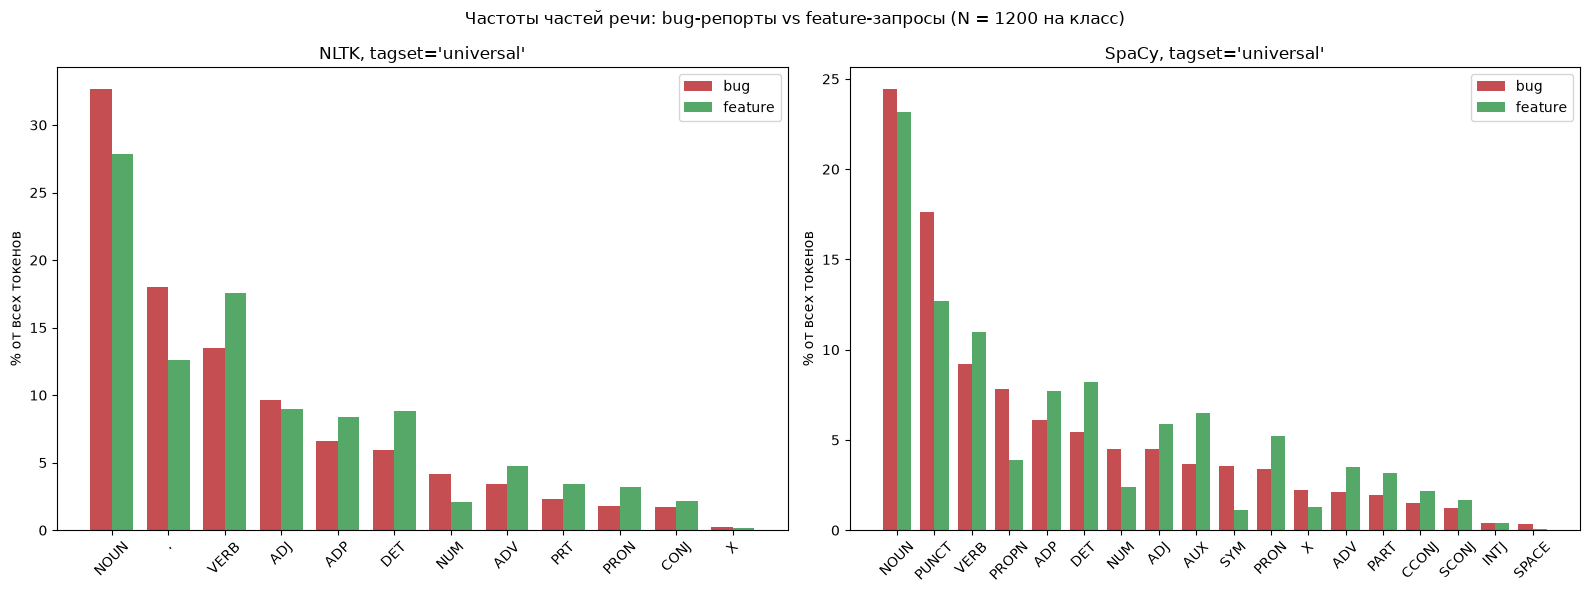

In [15]:
def plot_class_comparison(ax, dist_a, dist_b, label_a, label_b, title):
    tags = sorted(set(dist_a) | set(dist_b), key=lambda t: -dist_a.get(t, 0))
    x = np.arange(len(tags))
    width = 0.38

    vals_a = [dist_a.get(t, 0) for t in tags]
    vals_b = [dist_b.get(t, 0) for t in tags]

    ax.bar(x - width / 2, vals_a, width, label=label_a, color="#C44E52")
    ax.bar(x + width / 2, vals_b, width, label=label_b, color="#55A868")
    ax.set_xticks(x)
    ax.set_xticklabels(tags, rotation=45)
    ax.set_ylabel("% от всех токенов")
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_class_comparison(axes[0], nltk_bug_dist, nltk_feat_dist, "bug", "feature", "NLTK, tagset='universal'")
plot_class_comparison(axes[1], spacy_bug_dist, spacy_feat_dist, "bug", "feature", "SpaCy, tagset='universal'")
fig.suptitle(f"Частоты частей речи: bug-репорты vs feature-запросы (N = {N_CLASS} на класс)")
fig.tight_layout()
plt.show()

**Наблюдения по классам документов (согласуются у обоих тэггеров):**

- **`VERB` заметно выше в feature-запросах**, чем в bug-репортах: NLTK — 17.6% против 13.5%, SpaCy — 11.0% против 9.2%. Это объяснимо: feature-запросы — это предложения действий («add support», «allow users to», «implement»), а bug-репорты чаще описывают статичное неправильное состояние системы.
- **`NUM` заметно выше в bug-репортах**: NLTK — 4.2% против 2.1%, SpaCy — 4.5% против 2.4%. В багрепортах много номеров строк, версий, кодов ошибок, значений, которые должны/не должны получаться.
- **`PROPN` (SpaCy) почти вдвое выше в bug-репортах** — 7.8% против 3.9%. В описаниях багов чаще упоминаются конкретные имена: файлы, классы, библиотеки, имена пользователей из трассировок стека — всё то, что токенизируется как имя собственное.
- **`SYM` (SpaCy) выше в bug-репортах** — 3.6% против 1.1%: стектрейсы и команды содержат много символов (`/`, `::`, `--`, `<>`), которые не встречаются в более «текстовых» feature-запросах.
- `ADJ` отличается слабо (NLTK: 9.7% vs 9.0%; SpaCy: 4.5% vs 5.9%) — вопреки ожиданию, что в багрепортах будет больше оценочных прилагательных («broken», «wrong», «incorrect»), статистически значимой разницы по прилагательным не видно: эти слова чаще встречаются не в самом теле issue, а в заголовке (`issue_title`), по которому мы и определяли класс.

### Ошибки тэггеров на шуме и специфике датасета (5 примеров)

In [16]:
error_examples = [
    # (комментарий, текст)
    (
        "биомедицинская онтология: 'go:0010163', 'pmid:10629185' — идентификаторы, а не слова",
        "hi, i'd like to request the term high-affinity potassium ion import across plasma membrane "
        "child of go:0010163 high-affinity potassium ion import go:1990573 potassium ion import across "
        "plasma membrane standard def, ref pmid:10629185",
    ),
    (
        "интернет-сленг 'btw' (by the way)",
        "see title great work btw much improved over the last year",
    ),
    (
        "смешение языков (английский + немецкий) и упоминание пользователя",
        "@lespocky: bitte nehmt mich mit in organisation mit auf. thx :",
    ),
    (
        "python-стектрейс с путями к файлам и служебными токенами",
        "hi, game ended abrubtly, here's the relevant output: traceback most recent call last : "
        "file tuxemon/tuxemon.py , line 60, in <module> main",
    ),
    (
        "консольные команды docker вперемешку с естественным текстом",
        "ok for docker .. all done, find it there!: "
        "https://docs.docker.com/engine/installation/linux/docker-ce/ubuntu/ and chose amd instal "
        "for current cpu as intel too !! ... then i dl your herval pre_install docker .. but the "
        "build doesn't go on ! .. docker build -t herval/deepdream docker build requires exactly 1 argument.",
    ),
]

for comment, text in error_examples:
    print("=" * 100)
    print(f"[{comment}]")
    print(f"Текст: {text}")
    doc = nlp(text)
    print(f"SpaCy  (universal): {[(tok.text, tok.pos_) for tok in doc]}")
    print(f"NLTK   (universal): {pos_tag(word_tokenize(text), tagset='universal')}")
    print()

[биомедицинская онтология: 'go:0010163', 'pmid:10629185' — идентификаторы, а не слова]
Текст: hi, i'd like to request the term high-affinity potassium ion import across plasma membrane child of go:0010163 high-affinity potassium ion import go:1990573 potassium ion import across plasma membrane standard def, ref pmid:10629185
SpaCy  (universal): [('hi', 'INTJ'), (',', 'PUNCT'), ('i', 'PRON'), ("'d", 'AUX'), ('like', 'VERB'), ('to', 'PART'), ('request', 'VERB'), ('the', 'DET'), ('term', 'NOUN'), ('high', 'ADJ'), ('-', 'PUNCT'), ('affinity', 'NOUN'), ('potassium', 'NOUN'), ('ion', 'NOUN'), ('import', 'NOUN'), ('across', 'ADP'), ('plasma', 'NOUN'), ('membrane', 'NOUN'), ('child', 'NOUN'), ('of', 'ADP'), ('go:0010163', 'ADJ'), ('high', 'ADJ'), ('-', 'PUNCT'), ('affinity', 'NOUN'), ('potassium', 'NOUN'), ('ion', 'NOUN'), ('import', 'PROPN'), ('go:1990573', 'PROPN'), ('potassium', 'PROPN'), ('ion', 'NOUN'), ('import', 'NOUN'), ('across', 'ADP'), ('plasma', 'NOUN'), ('membrane', 'NOUN'), ('sta

**Разбор ошибок:**

1. **Онтологические ID (`go:0010163`, `pmid:10629185`).** Это не слова, а идентификаторы из биомедицинской онтологии Gene Ontology / PubMed ID, но тэггеры видят похожую на слово строку и гадают: SpaCy тегирует `go:0010163` как `ADJ`, а `go:1990573` в том же предложении — уже как `PROPN`; NLTK помечает оба как `ADJ`/`NOUN`. Правильного тега для таких идентификаторов в POS-разметке вообще нет — тэггерам неоткуда взять категорию «код/ID».
2. **`btw`** ("by the way", интернет-сокращение) функционально — вводное наречие/дискурсивный маркер, но отсутствует в обучающих корпусах обоих тэггеров. SpaCy помечает его как `AUX` (явная ошибка — не вспомогательный глагол), NLTK — как `ADV` (ближе к истине, но тоже натянуто). Соседнее слово `title` в императивном «see title» NLTK ошибочно тегирует как `ADJ` вместо `NOUN`.
3. **Смешение языков.** Текст на немецком ("bitte nehmt mich mit in organisation mit auf") оба тэггера, обученные на английском, тегируют почти случайно: немецкие глаголы `nehmt`, служебное слово `mit` (дважды, с разными "ошибочными" тегами — `PROPN`/`VERB` у SpaCy, `NOUN` у NLTK в обоих случаях) и частицу `auf` помечают как существительные/прилагательные/собственные имена. Упоминание `@lespocky` и сленг `thx` только усиливают разрушение разметки.
4. **Python-трассировка стека.** Служебное слово `traceback` (название секции трейса) SpaCy помечает как `VERB` вместо `NOUN`; `file` (начало строки трейса "File ...") — тоже `VERB` вместо `NOUN`/`PROPN`; путь `tuxemon/tuxemon.py` SpaCy разбивает на `tuxemon` (`NOUN`) + `/` (`SYM`) + `tuxemon.py` (`PROPN`), а NLTK склеивает весь путь в один токен `tuxemon/tuxemon.py` и помечает как `NOUN`; служебный токен `<module>` оба тэггера трактуют как обычную пунктуацию/прилагательное (`<` → `X`/`ADJ`), а `main` — как `ADJ` вместо `NOUN`/`PROPN` (имя функции). Специфика шума — программный код и служебная разметка трейса, которых нет в обучающих корпусах естественного языка.
5. **Консольные команды (`docker build -t herval/deepdream ...`).** Слово `docker` тегируется то как `NOUN`, то как `PROPN` (SpaCy) в зависимости от контекста в одном и том же предложении; флаг `-t` помечен как `PUNCT`/`ADJ` вместо служебного токена опции командной строки; сокращение `dl` ("download") тегируется как `VERB` (SpaCy, случайно верно по смыслу) и `ADV` (NLTK, неверно); URL SpaCy корректно сворачивает в один токен с тегом `X` (неизвестная категория), а NLTK токенизирует `//docs.docker.com/...` как отдельное "слово" с тегом `ADJ`. Главная причина ошибок — консольные команды и флаги являются доменно-специфичным «языком», которому тэггеры не обучены, а нижний регистр всего текста (`docker`, `herval`) лишает тэггеры единственной подсказки о том, что это имена собственные.

# Синтаксический анализ зависимостей (Dependency Parsing)

In [17]:
import re

from nltk.tokenize import sent_tokenize

SENT_SAMPLE_SIZE = 3000
sent_sample = df.sample(n=SENT_SAMPLE_SIZE, random_state=42)["body"].astype(str).tolist()


def is_clean_sentence(sent, tokens):
    if "http" in sent or "www." in sent:
        return False
    if sent.count(":") > 1 or "/" in sent or "\\" in sent:
        return False
    alpha_tokens = [t for t in tokens if t.isalpha()]
    if len(alpha_tokens) / len(tokens) < 0.85:
        return False
    if not re.match(r"^[a-z]", sent):
        return False
    if not sent.rstrip().endswith((".", "!", "?")):
        return False
    return True


candidate_sentences = []
for text in sent_sample:
    for sent in sent_tokenize(text):
        sent = sent.strip()
        tokens = word_tokenize(sent)
        if 9 <= len(tokens) <= 16 and is_clean_sentence(sent, tokens):
            candidate_sentences.append(sent)

print(f"Прошли автоматический фильтр: {len(candidate_sentences)} предложений из {SENT_SAMPLE_SIZE} документов")

Прошли автоматический фильтр: 1136 предложений из 3000 документов


In [18]:
# 10 предложений средней длины, вручную отобранных из отфильтрованных кандидатов выше
selected_sentences = [
    "the lan dns server will respond with an ip address on that lan.",
    "this slowly erodes the quality and simplicity of the library.",
    "any plans to have support for rn storybook?",
    "will alaska dhss share an expected timeline for the rfp for the first phase?",
    "i did like the older one much more.",
    "it might be better to call getkeys in this instance before having the exception thrown.",
    "this would be nice because it makes positioning of the caption and image easier.",
    "we should articulate and maintain a set of driving principles for the sarif format.",
    "please make sure to check the following boxes before submitting an issue.",
    "create a cleanup process that removed expired and executed callback resources.",
]

for i, sent in enumerate(selected_sentences, start=1):
    print(f"{i:>2}. ({len(word_tokenize(sent))} токенов) {sent}")

 1. (14 токенов) the lan dns server will respond with an ip address on that lan.
 2. (11 токенов) this slowly erodes the quality and simplicity of the library.
 3. (9 токенов) any plans to have support for rn storybook?
 4. (15 токенов) will alaska dhss share an expected timeline for the rfp for the first phase?
 5. (9 токенов) i did like the older one much more.
 6. (16 токенов) it might be better to call getkeys in this instance before having the exception thrown.
 7. (15 токенов) this would be nice because it makes positioning of the caption and image easier.
 8. (15 токенов) we should articulate and maintain a set of driving principles for the sarif format.
 9. (13 токенов) please make sure to check the following boxes before submitting an issue.
10. (12 токенов) create a cleanup process that removed expired and executed callback resources.


### Деревья синтаксических зависимостей (SpaCy, `pos_` = universal tagset)

In [19]:
print(type(doc))
print(dir(doc))

<class 'spacy.tokens.doc.Doc'>
['_', '__bytes__', '__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__ne__', '__new__', '__pyx_vtable__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__unicode__', '_bulk_merge', '_context', '_get_array_attrs', '_realloc', '_vector', '_vector_norm', 'cats', 'char_span', 'copy', 'count_by', 'doc', 'ents', 'extend_tensor', 'from_array', 'from_bytes', 'from_dict', 'from_disk', 'from_docs', 'from_json', 'get_extension', 'get_lca_matrix', 'has_annotation', 'has_extension', 'has_unknown_spaces', 'has_vector', 'is_nered', 'is_parsed', 'is_sentenced', 'is_tagged', 'lang', 'lang_', 'mem', 'noun_chunks', 'noun_chunks_iterator', 'remove_extension', 'retokenize', 'sentiment', 'sents', 'set_ents', 'set_extension

In [20]:
doc[0].head.text

'find'

In [21]:
from spacy import displacy

for i, sent in enumerate(selected_sentences, start=1):
    doc = nlp(sent)
    print(f"--- Предложение {i}: {sent}")
    for tok in doc:
        head = tok.head.text if tok.head != tok else "ROOT"
        print(f"  {tok.text:<12} pos={tok.pos_:<6} dep={tok.dep_:<10} head={head}")
    displacy.render(
        doc,
        style="dep",
        jupyter=True,
        options={"compact": True, "distance": 110, "fine_grained": False},
    )

--- Предложение 1: the lan dns server will respond with an ip address on that lan.
  the          pos=DET    dep=det        head=server
  lan          pos=PROPN  dep=compound   head=server
  dns          pos=NOUN   dep=compound   head=server
  server       pos=NOUN   dep=nsubj      head=respond
  will         pos=AUX    dep=aux        head=respond
  respond      pos=VERB   dep=ROOT       head=ROOT
  with         pos=ADP    dep=prep       head=respond
  an           pos=DET    dep=det        head=address
  ip           pos=NOUN   dep=compound   head=address
  address      pos=NOUN   dep=pobj       head=with
  on           pos=ADP    dep=prep       head=address
  that         pos=DET    dep=det        head=lan
  lan          pos=NOUN   dep=pobj       head=on
  .            pos=PUNCT  dep=punct      head=respond


--- Предложение 2: this slowly erodes the quality and simplicity of the library.
  this         pos=PRON   dep=nsubj      head=erodes
  slowly       pos=ADV    dep=advmod     head=erodes
  erodes       pos=VERB   dep=ROOT       head=ROOT
  the          pos=DET    dep=det        head=quality
  quality      pos=NOUN   dep=dobj       head=erodes
  and          pos=CCONJ  dep=cc         head=quality
  simplicity   pos=NOUN   dep=conj       head=quality
  of           pos=ADP    dep=prep       head=quality
  the          pos=DET    dep=det        head=library
  library      pos=NOUN   dep=pobj       head=of
  .            pos=PUNCT  dep=punct      head=erodes


--- Предложение 3: any plans to have support for rn storybook?
  any          pos=DET    dep=det        head=plans
  plans        pos=NOUN   dep=ROOT       head=ROOT
  to           pos=PART   dep=aux        head=have
  have         pos=AUX    dep=acl        head=plans
  support      pos=NOUN   dep=dobj       head=have
  for          pos=ADP    dep=prep       head=support
  rn           pos=ADP    dep=prep       head=have
  storybook    pos=NOUN   dep=pobj       head=rn
  ?            pos=PUNCT  dep=punct      head=plans


--- Предложение 4: will alaska dhss share an expected timeline for the rfp for the first phase?
  will         pos=AUX    dep=aux        head=share
  alaska       pos=PROPN  dep=compound   head=dhss
  dhss         pos=PROPN  dep=nsubj      head=share
  share        pos=VERB   dep=ROOT       head=ROOT
  an           pos=DET    dep=det        head=timeline
  expected     pos=VERB   dep=amod       head=timeline
  timeline     pos=NOUN   dep=dobj       head=share
  for          pos=ADP    dep=prep       head=timeline
  the          pos=DET    dep=det        head=rfp
  rfp          pos=PROPN  dep=pobj       head=for
  for          pos=ADP    dep=prep       head=share
  the          pos=DET    dep=det        head=phase
  first        pos=ADJ    dep=amod       head=phase
  phase        pos=NOUN   dep=pobj       head=for
  ?            pos=PUNCT  dep=punct      head=share


--- Предложение 5: i did like the older one much more.
  i            pos=PRON   dep=nsubj      head=like
  did          pos=AUX    dep=aux        head=like
  like         pos=VERB   dep=ROOT       head=ROOT
  the          pos=DET    dep=det        head=one
  older        pos=ADJ    dep=amod       head=one
  one          pos=NUM    dep=dobj       head=like
  much         pos=ADV    dep=advmod     head=more
  more         pos=ADJ    dep=amod       head=one
  .            pos=PUNCT  dep=punct      head=like


--- Предложение 6: it might be better to call getkeys in this instance before having the exception thrown.
  it           pos=PRON   dep=nsubj      head=be
  might        pos=AUX    dep=aux        head=be
  be           pos=AUX    dep=ROOT       head=ROOT
  better       pos=ADJ    dep=acomp      head=be
  to           pos=PART   dep=aux        head=call
  call         pos=VERB   dep=xcomp      head=be
  getkeys      pos=NOUN   dep=dobj       head=call
  in           pos=ADP    dep=prep       head=call
  this         pos=DET    dep=det        head=instance
  instance     pos=NOUN   dep=pobj       head=in
  before       pos=ADP    dep=prep       head=call
  having       pos=VERB   dep=pcomp      head=before
  the          pos=DET    dep=det        head=exception
  exception    pos=NOUN   dep=nsubj      head=thrown
  thrown       pos=VERB   dep=ccomp      head=having
  .            pos=PUNCT  dep=punct      head=be


--- Предложение 7: this would be nice because it makes positioning of the caption and image easier.
  this         pos=PRON   dep=nsubj      head=be
  would        pos=AUX    dep=aux        head=be
  be           pos=AUX    dep=ROOT       head=ROOT
  nice         pos=ADJ    dep=acomp      head=be
  because      pos=SCONJ  dep=mark       head=makes
  it           pos=PRON   dep=nsubj      head=makes
  makes        pos=VERB   dep=advcl      head=be
  positioning  pos=NOUN   dep=nsubj      head=easier
  of           pos=ADP    dep=prep       head=positioning
  the          pos=DET    dep=det        head=caption
  caption      pos=NOUN   dep=nmod       head=easier
  and          pos=CCONJ  dep=cc         head=caption
  image        pos=NOUN   dep=conj       head=caption
  easier       pos=ADJ    dep=ccomp      head=makes
  .            pos=PUNCT  dep=punct      head=be


--- Предложение 8: we should articulate and maintain a set of driving principles for the sarif format.
  we           pos=PRON   dep=nsubj      head=articulate
  should       pos=AUX    dep=aux        head=articulate
  articulate   pos=VERB   dep=ROOT       head=ROOT
  and          pos=CCONJ  dep=cc         head=articulate
  maintain     pos=VERB   dep=conj       head=articulate
  a            pos=DET    dep=det        head=set
  set          pos=NOUN   dep=dobj       head=maintain
  of           pos=ADP    dep=prep       head=set
  driving      pos=VERB   dep=pcomp      head=of
  principles   pos=NOUN   dep=dobj       head=driving
  for          pos=ADP    dep=prep       head=driving
  the          pos=DET    dep=det        head=format
  sarif        pos=PROPN  dep=compound   head=format
  format       pos=NOUN   dep=pobj       head=for
  .            pos=PUNCT  dep=punct      head=articulate


--- Предложение 9: please make sure to check the following boxes before submitting an issue.
  please       pos=INTJ   dep=intj       head=make
  make         pos=VERB   dep=ROOT       head=ROOT
  sure         pos=ADJ    dep=ccomp      head=make
  to           pos=PART   dep=aux        head=check
  check        pos=VERB   dep=xcomp      head=sure
  the          pos=DET    dep=det        head=boxes
  following    pos=VERB   dep=amod       head=boxes
  boxes        pos=NOUN   dep=dobj       head=check
  before       pos=ADP    dep=prep       head=check
  submitting   pos=VERB   dep=pcomp      head=before
  an           pos=DET    dep=det        head=issue
  issue        pos=NOUN   dep=dobj       head=submitting
  .            pos=PUNCT  dep=punct      head=make


--- Предложение 10: create a cleanup process that removed expired and executed callback resources.
  create       pos=VERB   dep=ROOT       head=ROOT
  a            pos=DET    dep=det        head=process
  cleanup      pos=NOUN   dep=compound   head=process
  process      pos=NOUN   dep=dobj       head=create
  that         pos=PRON   dep=nsubj      head=removed
  removed      pos=VERB   dep=relcl      head=process
  expired      pos=VERB   dep=conj       head=create
  and          pos=CCONJ  dep=cc         head=expired
  executed     pos=VERB   dep=conj       head=expired
  callback     pos=NOUN   dep=compound   head=resources
  resources    pos=NOUN   dep=dobj       head=executed
  .            pos=PUNCT  dep=punct      head=create


**Наблюдения по деревьям зависимостей:**

- В вопросительных и модальных предложениях (2, 4, 6) корнем (`ROOT`) становится не смысловой глагол, а вспомогательный/модальный (`will`, `might`), а основной глагол присоединяется через `xcomp`/`ccomp` — это типично для английского синтаксиса с составным сказуемым.
- В предложениях с придаточными (7-е — "because it makes...", 8-е — "that removed..., and executed...") парсер корректно вычленяет вложенные клаузы через `advcl`/`relcl`, что хорошо видно по дополнительной "ветке" дерева, отходящей от глагола главного предложения.
- В императиве (9-е, "please make sure to check...") корнем становится глагол `make` в повелительном наклонении без явного подлежащего — парсер верно не пытается найти для него `nsubj`.
- Специфика доменного текста issue-репортов (техническая лексика: `getkeys`, `rfp`, `sarif`, `dns`) не мешает парсеру строить синтаксически разумные деревья: зависимости строятся по структуре предложения, а не по словарю, поэтому незнакомые домену термины просто корректно встраиваются как обычные существительные/объекты (`dobj`, `pobj`) в общую структуру.

### GitHub-специфичные (шумные) примеры

10 предложений выше прошли строгий фильтр "чистоты" (без url/код/версий) — они хорошо показывают механику парсера, но не отражают специфику жанра. Добавим 5 предложений, которые, наоборот, намеренно взяты за то, что в них есть характерные для GitHub Issues шумные элементы: **упоминание (`@user`)**, **CLI-команда с `$`/флагами**, **semver-версии (`v10.3.5`)**, **сообщение об ошибке с двоеточием**, **имя exception-класса**.

In [22]:
github_specific_sentences = [
    "3:35 can you open up an github issue @pureween.",
    "find the attachment as travisexecution1.jpg $ git push origin master remote: invalid username or password.",
    "hi, we recently upgraded our tableau server to v10.3.5, and now tabmon v1.1 refuses to start up.",
    "i'm using expo to use this component and i keep getting this error: can you please let me know what am i doing wrong ?",
    "nullpointerexception is thrown when attempting to submit a previous immunization and no date and batch are inserted in the row.",
]

for i, sent in enumerate(github_specific_sentences, start=1):
    print(f"{i}. ({len(word_tokenize(sent))} токенов) {sent}")

1. (11 токенов) 3:35 can you open up an github issue @pureween.
2. (17 токенов) find the attachment as travisexecution1.jpg $ git push origin master remote: invalid username or password.
3. (20 токенов) hi, we recently upgraded our tableau server to v10.3.5, and now tabmon v1.1 refuses to start up.
4. (27 токенов) i'm using expo to use this component and i keep getting this error: can you please let me know what am i doing wrong ?
5. (21 токенов) nullpointerexception is thrown when attempting to submit a previous immunization and no date and batch are inserted in the row.


In [23]:
for i, sent in enumerate(github_specific_sentences, start=1):
    doc = nlp(sent)
    print(f"--- GitHub-пример {i}: {sent}")
    for tok in doc:
        head = tok.head.text if tok.head != tok else "ROOT"
        print(f"  {tok.text:<22} pos={tok.pos_:<6} dep={tok.dep_:<10} head={head}")
    displacy.render(
        doc,
        style="dep",
        jupyter=True,
        options={"compact": True, "distance": 110, "fine_grained": False},
    )

--- GitHub-пример 1: 3:35 can you open up an github issue @pureween.
  3:35                   pos=NUM    dep=npadvmod   head=open
  can                    pos=AUX    dep=aux        head=open
  you                    pos=PRON   dep=nsubj      head=open
  open                   pos=VERB   dep=ROOT       head=ROOT
  up                     pos=ADP    dep=prt        head=open
  an                     pos=DET    dep=det        head=issue
  github                 pos=NOUN   dep=compound   head=issue
  issue                  pos=NOUN   dep=dobj       head=open
  @pureween              pos=PROPN  dep=npadvmod   head=open
  .                      pos=PUNCT  dep=punct      head=open


--- GitHub-пример 2: find the attachment as travisexecution1.jpg $ git push origin master remote: invalid username or password.
  find                   pos=VERB   dep=ROOT       head=ROOT
  the                    pos=DET    dep=det        head=attachment
  attachment             pos=NOUN   dep=dobj       head=find
  as                     pos=ADP    dep=prep       head=find
  travisexecution1.jpg   pos=PUNCT  dep=punct      head=remote
  $                      pos=SYM    dep=nmod       head=remote
  git                    pos=NOUN   dep=compound   head=remote
  push                   pos=NOUN   dep=compound   head=origin
  origin                 pos=NOUN   dep=compound   head=remote
  master                 pos=PROPN  dep=compound   head=remote
  remote                 pos=PROPN  dep=pobj       head=as
  :                      pos=PUNCT  dep=punct      head=remote
  invalid                pos=ADJ    dep=amod       head=username
  username               pos=NOUN   dep=appos      head=r

--- GitHub-пример 3: hi, we recently upgraded our tableau server to v10.3.5, and now tabmon v1.1 refuses to start up.
  hi                     pos=INTJ   dep=intj       head=upgraded
  ,                      pos=PUNCT  dep=punct      head=upgraded
  we                     pos=PRON   dep=nsubj      head=upgraded
  recently               pos=ADV    dep=advmod     head=upgraded
  upgraded               pos=VERB   dep=ROOT       head=ROOT
  our                    pos=PRON   dep=poss       head=server
  tableau                pos=NOUN   dep=compound   head=server
  server                 pos=NOUN   dep=dobj       head=upgraded
  to                     pos=ADP    dep=prep       head=upgraded
  v10.3.5                pos=PROPN  dep=pobj       head=to
  ,                      pos=PUNCT  dep=punct      head=upgraded
  and                    pos=CCONJ  dep=cc         head=upgraded
  now                    pos=ADV    dep=advmod     head=refuses
  tabmon                 pos=NOUN   dep=compound   h

--- GitHub-пример 4: i'm using expo to use this component and i keep getting this error: can you please let me know what am i doing wrong ?
  i                      pos=PRON   dep=nsubj      head=using
  'm                     pos=AUX    dep=aux        head=using
  using                  pos=VERB   dep=ccomp      head=let
  expo                   pos=NOUN   dep=dobj       head=using
  to                     pos=PART   dep=aux        head=use
  use                    pos=VERB   dep=xcomp      head=using
  this                   pos=DET    dep=det        head=component
  component              pos=NOUN   dep=dobj       head=use
  and                    pos=CCONJ  dep=cc         head=using
  i                      pos=PRON   dep=nsubj      head=keep
  keep                   pos=VERB   dep=conj       head=using
  getting                pos=VERB   dep=xcomp      head=keep
  this                   pos=DET    dep=det        head=error
  error                  pos=NOUN   dep=dobj       head=ge

--- GitHub-пример 5: nullpointerexception is thrown when attempting to submit a previous immunization and no date and batch are inserted in the row.
  nullpointerexception   pos=NOUN   dep=nsubjpass  head=thrown
  is                     pos=AUX    dep=auxpass    head=thrown
  thrown                 pos=VERB   dep=ROOT       head=ROOT
  when                   pos=SCONJ  dep=advmod     head=attempting
  attempting             pos=VERB   dep=advcl      head=thrown
  to                     pos=PART   dep=aux        head=submit
  submit                 pos=VERB   dep=xcomp      head=attempting
  a                      pos=DET    dep=det        head=immunization
  previous               pos=ADJ    dep=amod       head=immunization
  immunization           pos=NOUN   dep=dobj       head=submit
  and                    pos=CCONJ  dep=cc         head=immunization
  no                     pos=DET    dep=det        head=date
  date                   pos=NOUN   dep=conj       head=immunization
  an

# Извлечение паттернов

пары **[Существительное (аспект) + Прилагательное (оценка)]**. Для GitHub Issues это выглядит как: аспект — компонент системы (`api`, `build`, `tag`, `behavior`, `documentation`), оценка — прилагательное, которое его характеризует (`broken`, `confusing`, `invalid`, `outdated`).

Функция обходит дерево зависимостей предложения и ищет пару "аспект+оценка" по трём синтаксическим паттернам:

1. **Атрибутивный (`amod`)** — прилагательное напрямую определяет существительное: *"a `confusing` **api**"* → `(api, confusing)`.
2. **Предикативный через `acomp`** — прилагательное является именной частью сказуемого при связочном глаголе (`be`, `seem`, `look`, `feel`, `remain`...), а подлежащее этого глагола — существительное: *"the **documentation** remains `outdated`"* → `(documentation, outdated)`.
3. **Предикативный с прямым `nsubj` у прилагательного** — на случай, если парсер делает прилагательное корнем предложения (а не `AUX`): *"**build** `broken`"* → `(build, broken)`. В `en_core_web_sm` эта ветка почти не срабатывает (парсер обычно выбирает корнем связочный глагол), но оставлена для полноты алгоритма.

In [24]:
#  список всех доступных значений dep

for label in nlp.get_pipe("parser").labels:
    print(label, " -- ", spacy.explain(label))

ROOT  --  root
acl  --  clausal modifier of noun (adjectival clause)
acomp  --  adjectival complement
advcl  --  adverbial clause modifier
advmod  --  adverbial modifier
agent  --  agent
amod  --  adjectival modifier
appos  --  appositional modifier
attr  --  attribute
aux  --  auxiliary
auxpass  --  auxiliary (passive)
case  --  case marking
cc  --  coordinating conjunction
ccomp  --  clausal complement
compound  --  compound
conj  --  conjunct
csubj  --  clausal subject
csubjpass  --  clausal subject (passive)
dative  --  dative
dep  --  unclassified dependent
det  --  determiner
dobj  --  direct object
expl  --  expletive
intj  --  interjection
mark  --  marker
meta  --  meta modifier
neg  --  negation modifier
nmod  --  modifier of nominal
npadvmod  --  noun phrase as adverbial modifier
nsubj  --  nominal subject
nsubjpass  --  nominal subject (passive)
nummod  --  numeric modifier
oprd  --  object predicate
parataxis  --  parataxis
pcomp  --  complement of preposition
pobj  --  ob

/Users/hq-q05j3pd44y/Documents/vscode/itmo-texts-anaysis-course-2026/venv/lib/python3.12/site-packages/spacy/glossary.py:20: UserWarning: [W118] Term 'predet' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))


In [25]:
def extract_noun_adj_pairs(doc):
    """Обходит дерево зависимостей SpaCy-документа и извлекает пары
    [существительное (аспект), прилагательное (оценка)] вместе с типом синтаксической связи.
    Возвращает список кортежей (noun_lemma, adj_lemma, pattern).
    """
    pairs = []
    for token in doc:
        if token.pos_ != "ADJ":
            continue

        if token.dep_ == "amod" and token.head.pos_ in ("NOUN", "PROPN"):
            pairs.append((token.head.lemma_.lower(), token.lemma_.lower(), "amod"))

        for child in token.children:
            if child.dep_ in ("nsubj", "nsubjpass") and child.pos_ in ("NOUN", "PROPN"):
                pairs.append((child.lemma_.lower(), token.lemma_.lower(), "nsubj-adj"))

        if token.dep_ == "acomp":
            verb = token.head
            for child in verb.children:
                if child.dep_ in ("nsubj", "nsubjpass") and child.pos_ in ("NOUN", "PROPN"):
                    pairs.append((child.lemma_.lower(), token.lemma_.lower(), "acomp"))

    return pairs

### Применение алгоритма к выборке датасета

In [26]:
from collections import Counter

PATTERN_SAMPLE_SIZE = 5000
pattern_sample = df.sample(n=PATTERN_SAMPLE_SIZE, random_state=42)["body"].astype(str).tolist()

pattern_sentences = []
for text in pattern_sample:
    for s in sent_tokenize(text):
        n = len(word_tokenize(s))
        if 5 <= n <= 25:
            pattern_sentences.append(s)

print(f"Предложений для анализа: {len(pattern_sentences)}")

all_noun_adj_pairs = []       # (noun_lemma, adj_lemma, pattern) по всем предложениям
pair_sentence_examples = []   # (исходное предложение, найденные в нём пары) — только непустые

for doc in nlp.pipe(pattern_sentences, batch_size=128, disable=["ner"]):
    pairs = extract_noun_adj_pairs(doc)
    if pairs:
        all_noun_adj_pairs.extend(pairs)
        pair_sentence_examples.append((doc.text, pairs))

print(f"Всего извлечено пар [существительное + прилагательное]: {len(all_noun_adj_pairs)}")
print(f"Предложений, где нашлась хотя бы одна пара: {len(pair_sentence_examples)}")

Предложений для анализа: 10677


Всего извлечено пар [существительное + прилагательное]: 5675
Предложений, где нашлась хотя бы одна пара: 4222


In [27]:
import random

random.seed(42)
for sent, pairs in random.sample(pair_sentence_examples, 15):
    print(f"- {sent}\n    -> {pairs}")

- options for responsive design: break columns / break rows / no break will need scrolling
    -> [('design', 'responsive', 'amod')]
- hi, where can i find the version 1.0.3 outside playstore ?
    -> [('playstore', 'outside', 'amod')]
- tutorial issue found: https://github.com/alenapetsyeva/alenatut/blob/master/tutorials/angular-add-javascript/angular-add-javascript.md https://github.com/alenapetsyeva/alenatut/blob/master/tutorials/angular-add-javascript/angular-add-javascript.md contains invalid tags.
    -> [('issue', 'tutorial', 'amod'), ('tag', 'invalid', 'amod')]
- the data i'm getting back looks like hex data with the ok code at the start .
    -> [('code', 'ok', 'amod')]
- what is the expected behavior?
    -> [('behavior', 'expected', 'amod')]
- - record all any new terminal commands you used this week in the waffle comments below.
    -> [('terminal', 'new', 'amod')]
- looks like config only supports a single signing key.
    -> [('key', 'single', 'amod')]
- however, due to t

# Анализ извлечённых паттернов

Считаем частоту уже извлечённых в п.4 пар, группируя по лемме `(существительное, прилагательное)` независимо от типа синтаксической связи (`amod`/`acomp`/`nsubj-adj`).

In [28]:
pair_counter = Counter((noun, adj) for noun, adj, _ in all_noun_adj_pairs)
total_pairs = sum(pair_counter.values())

print(f"Уникальных пар: {len(pair_counter)} из {total_pairs} извлечений\n")
print(f"{'#':>3}  {'существительное':<16}{'прилагательное':<16}{'кол-во':>7}{'доля':>8}")
top20 = pair_counter.most_common(20)
for rank, ((noun, adj), cnt) in enumerate(top20, start=1):
    print(f"{rank:>3}  {noun:<16}{adj:<16}{cnt:>7}{cnt / total_pairs * 100:>7.1f}%")

Уникальных пар: 4593 из 5675 извлечений

  #  существительное прилагательное   кол-во    доля
  1  issue           tutorial             36    0.6%
  2  behavior        actual               33    0.6%
  3  version         late                 28    0.5%
  4  tag             invalid              27    0.5%
  5  behavior        current              25    0.4%
  6  version         new                  20    0.4%
  7  issue           original             15    0.3%
  8  tag             primary              14    0.2%
  9  behavior        expected             13    0.2%
 10  request         pull                 12    0.2%
 11  version         old                  11    0.2%
 12  result          actual               11    0.2%
 13  branch          new                   9    0.2%
 14  information     more                  9    0.2%
 15  information     additional            9    0.2%
 16  issue           similar               8    0.1%
 17  release         late                  8    0.1%
 18  

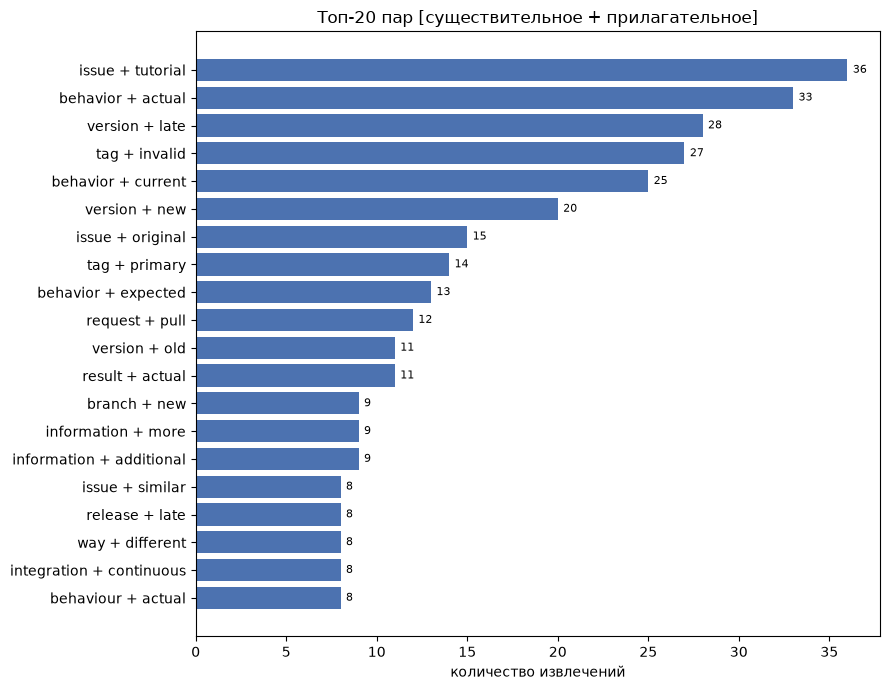

In [29]:
fig, ax = plt.subplots(figsize=(9, 7))
labels = [f"{noun} + {adj}" for (noun, adj), _ in reversed(top20)]
values = [cnt for _, cnt in reversed(top20)]

ax.barh(labels, values, color="#4C72B0")
ax.set_xlabel("количество извлечений")
ax.set_title("Топ-20 пар [существительное + прилагательное]")
for i, v in enumerate(values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=8)
fig.tight_layout()
plt.show()

**Насколько топ-20 пар отражает суть и тональность датасета:**

- **Топ-20 почти целиком состоит из шаблонной лексики баг-репортов**, а не из органических оценочных суждений: `actual/current/expected behavior`, `new/old/late version`, `invalid/primary tag`, `pull request`, `continuous integration`, `original/similar issue`. Это не случайность — GitHub предлагает авторам issue фиксированные секции шаблона ("Expected Behavior" / "Actual Behavior", "Steps to Reproduce" и т.п.), и эти заголовки массово копируются из issue в issue.
- Часть пар синтаксически корректны (`amod`), но семантически это не "аспект+оценка", а **устойчивые технические термины**: `pull request`, `continuous integration` — особенность переноса паттерна [NOUN+ADJ] на техническую документацию.
- **Вывод:** топ-20 синтаксических пар по сырой частоте хорошо отражает **предметную область и жанр** текстов (баг-репорты, версии, теги, CI/CD), но почти не отражает **тональность** — она присутствует в данных, но размыта по длинному хвосту редких пар.

# Разрешение анафоры (Rule-based)

Ищем местоимения 3-го лица — аналоги «он / она / они / это»: **he, she, it, they** (плюс их словоформы `him/his`, `her`, `its`, `them/their`). Алгоритм полностью rule-based, без нейросетевого coreference-резолвера — использует только морфологию и синтаксис, которые уже даёт SpaCy.

**Морфологические признаки:**
- **Число** — `token.morph.get("Number")` (`Sing`/`Plur`) у местоимения и у кандидатов-существительных.
- **"Род"** — в английском у существительных нет грамматического рода, поэтому вместо муж./жен./сред. рода используется его функциональный аналог — бинарный признак **одушевлённости/класса**: `person` (существительное обозначает человека — по NER `ent_type_ == "PERSON"` или по словарю `PERSON_NOUNS`: `user`, `developer`, `maintainer`, `team`...) против `thing` (всё остальное). `he/she/him/her/his` требуют антецедент класса `person`, `it/its` — класса `thing`, `they/them/their` — число `Plur` любого класса **или** `person` в единственном числе (неопределённый по полу человек).

**Синтаксическое расстояние:** кандидаты — существительные (`NOUN`/`PROPN`), ищутся в окне «текущее предложение + 2 предыдущих». Среди кандидатов, прошедших фильтр по числу/классу, выбирается ближайший по правилу: 1) минимальное расстояние в предложениях, 2) предпочтение подлежащему (`nsubj`/`nsubjpass`) как самому "заметному" (salient) кандидату, 3) минимальное расстояние в токенах.

In [30]:
PERSON_NOUNS = {
    "developer", "developers", "user", "users", "maintainer", "maintainers", "author", "authors",
    "contributor", "contributors", "admin", "admins", "administrator", "administrators", "person", "people",
    "someone", "anyone", "everyone", "team", "teams", "member", "members", "guy", "guys", "dev", "devs",
    "engineer", "engineers", "tester", "testers", "customer", "customers", "client", "clients",
    "reviewer", "reviewers", "owner", "owners", "reporter", "reporters", "colleague", "colleagues",
    "friend", "friends", "manager", "managers", "programmer", "programmers",
}

# число и "класс" (аналог рода) для каждого целевого местоимения 3-го лица
PRONOUN_INFO = {
    "he": {"number": "Sing", "cls": "person", "poss": False},
    "him": {"number": "Sing", "cls": "person", "poss": False},
    "his": {"number": "Sing", "cls": "person", "poss": True},
    "she": {"number": "Sing", "cls": "person", "poss": False},
    "her": {"number": "Sing", "cls": "person", "poss": False},
    "it": {"number": "Sing", "cls": "thing", "poss": False},
    "its": {"number": "Sing", "cls": "thing", "poss": True},
    "they": {"number": "Plur", "cls": "any", "poss": False},
    "them": {"number": "Plur", "cls": "any", "poss": False},
    "their": {"number": "Plur", "cls": "any", "poss": True},
}


def noun_class(token):
    """'person' или 'thing' — функциональный аналог рода для английского."""
    if token.ent_type_ == "PERSON":
        return "person"
    if token.lemma_.lower() in PERSON_NOUNS:
        return "person"
    return "thing"


def noun_number(token):
    nums = token.morph.get("Number")
    if nums:
        return nums[0]
    return "Plur" if token.tag_ in ("NNS", "NNPS") else "Sing"


def is_pleonastic_it(token):
    """Фиктивное 'it' в конструкциях экстрапозиции: 'it is ADJ (that/to ...)'."""
    if token.text.lower() != "it" or token.dep_ not in ("nsubj", "nsubjpass"):
        return False
    head = token.head
    if head.lemma_ not in ("be", "seem", "appear", "look", "happen", "turn"):
        return False
    return any(c.dep_ in ("xcomp", "ccomp", "advcl") for c in head.children)

In [31]:
def find_antecedent(doc, pronoun_tok, sent_list, max_sent_back=2):
    """Ищет ближайшее по синтаксическому расстоянию существительное-антецедент,
    согласованное с местоимением по числу и 'классу' (person/thing)."""
    info = PRONOUN_INFO[pronoun_tok.text.lower()]
    sent_idx = next(i for i, s in enumerate(sent_list) if s.start <= pronoun_tok.i < s.end)
    window_start = sent_list[max(0, sent_idx - max_sent_back)].start

    candidates = []
    for tok in doc[window_start:pronoun_tok.i]:
        if tok.pos_ not in ("NOUN", "PROPN") or tok.text.lower() in PRONOUN_INFO:
            continue
        cls, num = noun_class(tok), noun_number(tok)
        number_ok = (
            num == info["number"]
            or (info["cls"] == "any" and num == "Plur")
            or (info["cls"] == "any" and num == "Sing" and cls == "person")
        )
        class_ok = info["cls"] == "any" or cls == info["cls"]
        c_sent_idx = next(i for i, s in enumerate(sent_list) if s.start <= tok.i < s.end)
        sent_dist = sent_idx - c_sent_idx
        tok_dist = pronoun_tok.i - tok.i
        is_subj = tok.dep_ in ("nsubj", "nsubjpass")
        candidates.append((number_ok, class_ok, sent_dist, tok_dist, is_subj, tok))

    strict = [c for c in candidates if c[0] and c[1]]
    # если нет кандидата, согласованного и по числу, и по классу - ослабляем требование по классу
    pool = strict if strict else [c for c in candidates if c[0]]
    if not pool:
        return None, "no_candidate"

    pool.sort(key=lambda c: (c[2], -int(c[4]), c[3]))
    return pool[0][5], ("strict" if strict else "relaxed_class")


def resolve_pronouns_in_text(text):
    doc = nlp(text)
    sent_list = list(doc.sents)
    resolutions = []
    for tok in doc:
        if tok.text.lower() not in PRONOUN_INFO or tok.pos_ != "PRON":
            continue
        if is_pleonastic_it(tok):
            resolutions.append((tok, None, "pleonastic_it"))
            continue
        antecedent, reason = find_antecedent(doc, tok, sent_list)
        resolutions.append((tok, antecedent, reason))
    return doc, resolutions


def render_replacement(doc, resolutions):
    """Заменяет каждое разрешённое местоимение на текст антецедента (посессив -> + \'s)."""
    tokens = [t.text_with_ws for t in doc]
    for tok, antecedent, reason in resolutions:
        if antecedent is None:
            continue
        replacement = antecedent.text
        if PRONOUN_INFO[tok.text.lower()]["poss"]:
            replacement += "'s"
        if tok.text[0].isupper():
            replacement = replacement.capitalize()
        tokens[tok.i] = replacement + doc[tok.i].whitespace_
    return "".join(tokens)

### Пример

In [32]:
demo_text = (
    "The developer fixed the bug. He also updated the documentation because it was outdated. "
    "The users reported that they were happy with the fix."
)
doc, resolutions = resolve_pronouns_in_text(demo_text)

print("ORIG:", doc.text)
for tok, antecedent, reason in resolutions:
    print(f"  {tok.text!r:8} -> {antecedent.text if antecedent else None} ({reason})")
print("NEW :", render_replacement(doc, resolutions))

ORIG: The developer fixed the bug. He also updated the documentation because it was outdated. The users reported that they were happy with the fix.
  'He'     -> developer (strict)
  'it'     -> documentation (strict)
  'they'   -> users (strict)
NEW : The developer fixed the bug. Developer also updated the documentation because documentation was outdated. The users reported that users were happy with the fix.


### Применение к реальным issue из датасета

Ниже — подобранные вручную примеры из корпуса (по 2-4 на каждое местоимение `it/they/he/she`), где алгоритм нашёл хотя бы один антецедент. Показаны исходное предложение, решение по каждому местоимению (антецедент + причина: `strict` — совпали число и класс, `relaxed_class` — класс ослаблен из-за отсутствия подходящего кандидата, `pleonastic_it` — фиктивное `it` не заменяется) и итоговый текст с заменой.

In [33]:
curated_examples = [
    # [she] — верное разрешение на именованную сущность
    "esther is going to manually shorten the urls for the visitor website, so instead of adding the "
    "url to the qr-code, we will put all the urls in a text file in the zip file and she will "
    "manually generate the shortened urls and put them on the sign.",
    # [he/she] — оба местоимения корректно разрешены в "user"
    "is it possible to add an way that 2fa is forced? because now you manually have to enable it "
    "for every user and if you don't enable it for one he/she can still log in without 2fa.",
    # [it] — плеонастическое it корректно пропущено + второе it разрешено верно
    "is it possible to add a text link in the content of one tab, so that it opens another tab?",
    # [it] — плеонастическое it пропущено, предикативное it разрешено НЕверно (число/референт не совпали по смыслу)
    "it would be nice if the files listed in the quick search ctrl+shift+l will become editable "
    "in the bottom box, with the possibility to save it. thanks! alessandroc",
    # [they] — оба местоимения "they" в тексте корректно разрешены в "labels"
    "the labels on on the chart improperly overlap. for example, currently they show: notice how "
    "the left-most interval says 123040-125056, and the next one says 125056-127072. they should "
    "instead be: 123040-125055 and 125056-127071, etc.",
    # [they/it] — несколько местоимений в одном issue, разные антецеденты
    "original gyp puts compilation results to obj/${intprefix} dir if they are of some specific "
    "types which differ by platform. i'm not sure how to fix it at this moment, but node uses this "
    "feature of gyp when linking to v8/openssl. we need to fix it somehow.",
    # [she] — "alexa" (голосовой ассистент) не распознана как person ни NER, ни словарём person-существительных,
    # поэтому в окне не находится ни одного подходящего кандидата, и местоимение остаётся неразрешённым
    "i can't find info on how to set that all up. can someone help me? "
    "i call so hard i can alexa, but she is still ignoring me :",
    # [he] — ошибка: url, стоящий перед местоимением, по ошибке выбран кандидатом вместо имени "alexi"
    "https://gist.github.com/boutell/5e31025e7e29d0fa4d91 asked alexi and he did not now",
    # [it/he] — упоминание @mention корректно распознано как person-кандидат для he
    "in order to show the changes on the actual website please learn how to update the server and "
    "re-run it from @mburakergenc, i believe he has access.",
]

for text in curated_examples:
    doc, resolutions = resolve_pronouns_in_text(text)
    print("ORIG:", doc.text)
    for tok, antecedent, reason in resolutions:
        print(f"   {tok.text!r:8} -> {antecedent.text if antecedent else None} ({reason})")
    print("NEW :", render_replacement(doc, resolutions))
    print()

ORIG: esther is going to manually shorten the urls for the visitor website, so instead of adding the url to the qr-code, we will put all the urls in a text file in the zip file and she will manually generate the shortened urls and put them on the sign.
   'she'    -> esther (relaxed_class)
   'them'   -> urls (strict)
NEW : esther is going to manually shorten the urls for the visitor website, so instead of adding the url to the qr-code, we will put all the urls in a text file in the zip file and esther will manually generate the shortened urls and put urls on the sign.

ORIG: is it possible to add an way that 2fa is forced? because now you manually have to enable it for every user and if you don't enable it for one he/she can still log in without 2fa.
   'it'     -> None (pleonastic_it)
   'it'     -> 2fa (strict)
   'it'     -> 2fa (strict)
   'he'     -> user (strict)
   'she'    -> user (strict)
NEW : is it possible to add an way that 2fa is forced? because now you manually have to 

ORIG: the labels on on the chart improperly overlap. for example, currently they show: notice how the left-most interval says 123040-125056, and the next one says 125056-127072. they should instead be: 123040-125055 and 125056-127071, etc.
   'they'   -> labels (strict)
   'they'   -> labels (strict)
NEW : the labels on on the chart improperly overlap. for example, currently labels show: notice how the left-most interval says 123040-125056, and the next one says 125056-127072. labels should instead be: 123040-125055 and 125056-127071, etc.



ORIG: original gyp puts compilation results to obj/${intprefix} dir if they are of some specific types which differ by platform. i'm not sure how to fix it at this moment, but node uses this feature of gyp when linking to v8/openssl. we need to fix it somehow.
   'they'   -> results (strict)
   'it'     -> gyp (strict)
   'it'     -> node (strict)
NEW : original gyp puts compilation results to obj/${intprefix} dir if results are of some specific types which differ by platform. i'm not sure how to fix gyp at this moment, but node uses this feature of gyp when linking to v8/openssl. we need to fix node somehow.

ORIG: i can't find info on how to set that all up. can someone help me? i call so hard i can alexa, but she is still ignoring me :
   'she'    -> info (relaxed_class)
NEW : i can't find info on how to set that all up. can someone help me? i call so hard i can alexa, but info is still ignoring me :

ORIG: https://gist.github.com/boutell/5e31025e7e29d0fa4d91 asked alexi and he did 

**Сравнение исходных и изменённых предложений, разбор качества:**

- **Удачные случаи:** `she -> esther` (именованная сущность, первая по тексту, число и класс совпали через relaxed-ветку); `he` и `she` в одном предложении оба корректно разрешились в `user` (классический паттерн "for every user ... he/she" — алгоритм верно использовал один и тот же близкий сингулярный "person"-кандидат для обоих местоимений); `it -> tab` и `they -> labels/results` — там, где антецедент является ближайшим подлежащим подходящего числа, rule-based подход работает почти как ожидается; `he -> @mburakergenc` показывает, что GitHub-упоминания (`@user`) успешно работают как "person"-кандидаты, хотя они не входят в словарь `PERSON_NOUNS` — помогло то, что других кандидатов рядом не было (ветка `relaxed_class`).
- **Плеонастическое `it`:** в двух примерах (*"is it possible..."*, *"it would be nice if..."*) фиктивное `it` в конструкции экстрапозиции корректно не заменяется — это именно то поведение, которое и задумывалось правилом `is_pleonastic_it`.
- **Типичные ошибки:**
  1. *"она всё ещё меня игнорирует"* про голосового ассистента **alexa** — наш бинарный признак "класса" (`person` по NER/словарю) не распознаёт личность у неодушевлённых, но персонифицируемых сущностей (имена устройств/продуктов), поэтому `she` уходит на случайный ближайший `thing`-кандидат (`info`). Нужен был бы словарь продуктовых имён или NER-модель получше.
  2. **URL как существительное-кандидат** — `he` разрешилось в длинный `http://...` токен вместо имени `alexi`: SpaCy помечает URL как `PROPN`, и наш фильтр кандидатов не исключает такие токены явно. Системная проблема шумного текста issue, с которой мы уже сталкивались в п.2–4.
  3. **Несовпадение числа антецедента и реального референта** в примере с `save it` — пользователь, скорее всего, имел в виду множественное `files`, но местоимение стоит в единственном числе (обычная для разговорного английского небрежность), а наш алгоритм по формальному правилу согласования числа подбирает ближайший singular-кандидат (`possibility`), который синтаксически ближе, но семантически неверен.
- **Итог:** rule-based резолюция анафоры на основе числа, "класса" (person/thing) и расстояния в предложениях работает приемлемо для чистых, грамматически правильных конструкций (особенно для подлежащных местоимений рядом с их антецедентом), но закономерно ошибается там, где нужна либо внешняя лексическая база знаний (персонификация брендов/устройств), либо фильтрация шумных кандидатов (url), либо устойчивость к неформальному нарушению согласования числа — то есть именно в тех местах, где простые морфосинтаксические правила принципиально не могут заменить семантику.